In [2]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed = 42)
print(f"imports ok, noise range = {rng}")

imports ok, noise range = Generator(PCG64)


In [3]:
dt = 0.01        # bin width: 10 milliseconds
t_pre  = 2.0     # seconds of quiet before the burst
t_post = 15.0    # seconds after burst onset

t = np.arange(-t_pre, t_post, dt)

print(f"Total bins: {len(t)}")
print(f"Time runs from {t[0]:.1f}s to {t[-1]:.2f}s")


Total bins: 1700
Time runs from -2.0s to 14.99s


In [4]:
bg_rate = 0.5
bg_mean = bg_rate * dt
background = rng.poisson(bg_mean, size = len(t))

print(f"Mean background per bin: {bg_mean}")
print(f"Total background events: {background.sum()}")

Mean background per bin: 0.005
Total background events: 9


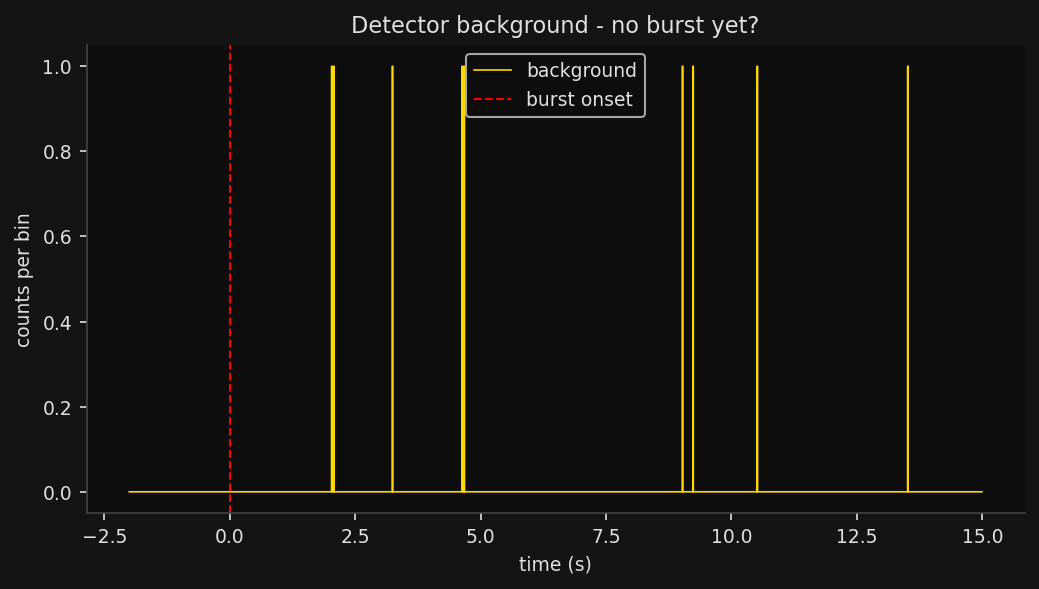

In [6]:
# plot the background
plt.Figure(figsize = (12,3))
plt.step(t, background, color = 'gold', linewidth = 0.8, label = "background")

plt.axvline(0, color='red', linestyle='--', linewidth=1, label='burst onset')
plt.xlabel("time (s)")
plt.ylabel("counts per bin")
plt.title("Detector background - no burst yet?")
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
def burst_luminosity(t, t0=0.0, tau=3.0, peak_rate=200.0):
    signal = np.zeros_like(t)
    mask = t >= t0
    signal[mask] = peak_rate * np.exp(-(t[mask] - t0) / tau)
    return signal

signal_rate = burst_luminosity(t)
signal_mean = signal_rate * dt
signal = rng.poisson(signal_mean)

print(f"Peak signal rate: {signal_rate.max():.1f} events/s")
print(f"Total signal events: {signal.sum()}")

Peak signal rate: 200.0 events/s
Total signal events: 607


In [8]:
observed = background + signal

print(f"Total observed events: {observed.sum()}")
print(f"Peak observed counts in a single bin: {observed.max()}")


Total observed events: 616
Peak observed counts in a single bin: 6


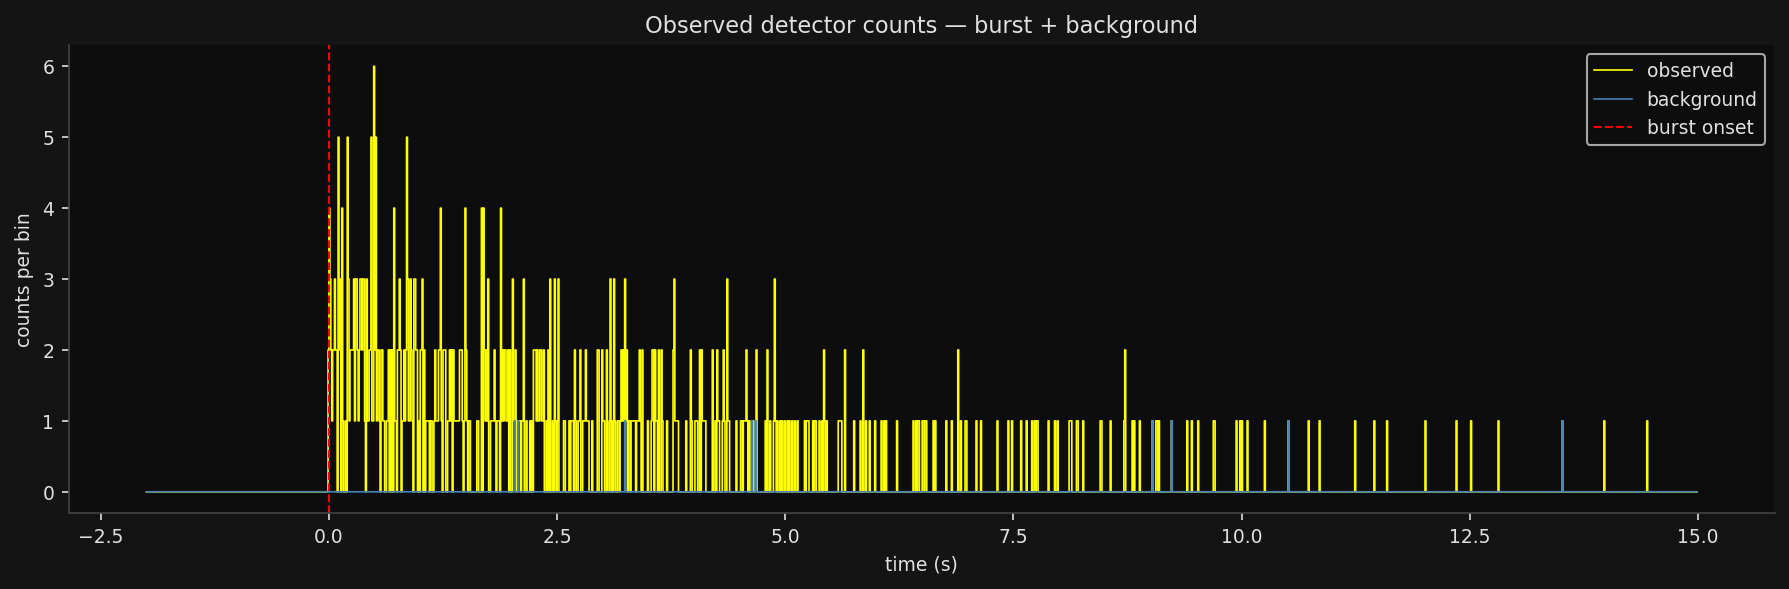

In [9]:
plt.figure(figsize=(12, 4))
plt.step(t, observed, color='yellow', linewidth=0.8, label='observed')
plt.step(t, background, color='steelblue', linewidth=0.8, label='background')
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='burst onset')
plt.xlabel('time (s)')
plt.ylabel('counts per bin')
plt.title('Observed detector counts — burst + background')
plt.legend()
plt.tight_layout()
plt.savefig("plots/01_background.png", dpi = 150)
print("saved to plots/")
plt.show()


In [10]:
window_sec = 0.5
window_bins = int(window_sec / dt)

smoothed = np.convolve(observed, np.ones(window_bins)/window_bins, mode='same')
bg_smoothed = bg_rate * dt

detection_ratio = smoothed / bg_smoothed

print(f"Window size: {window_bins} bins ({window_sec}s)")
print(f"Peak detection ratio: {detection_ratio.max():.1f}x above background")


Window size: 50 bins (0.5s)
Peak detection ratio: 424.0x above background


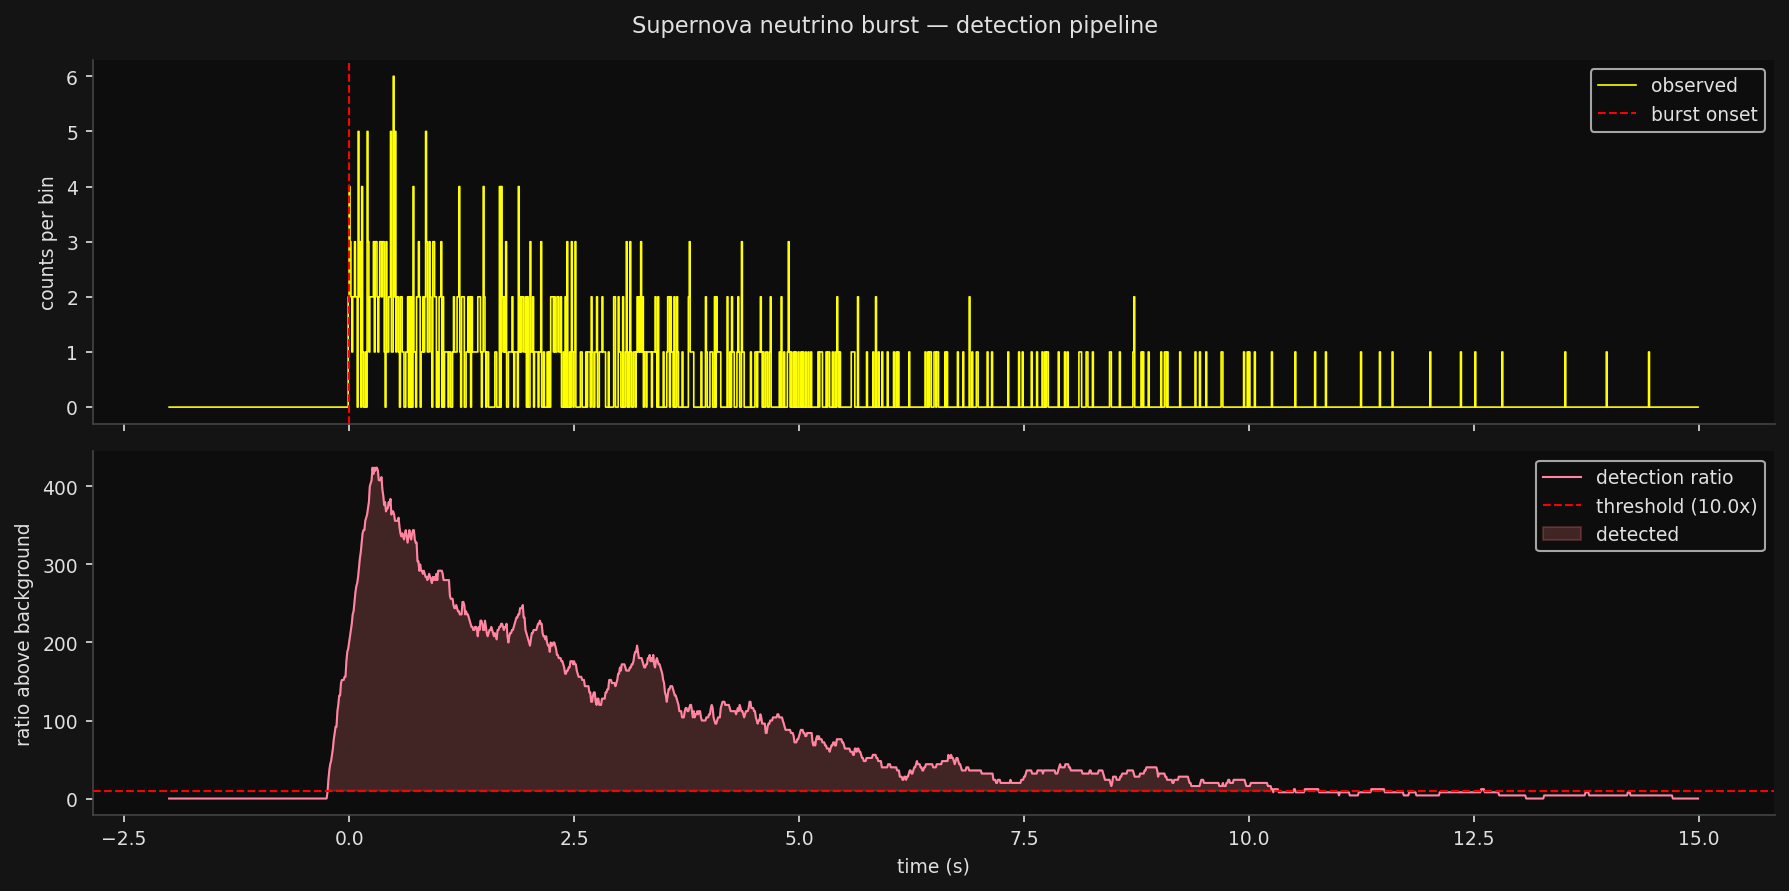

In [16]:
threshold = 10.0

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.step(t, observed, color='yellow', linewidth=0.8, label='observed')
ax1.axvline(0, color='red', linestyle='--', linewidth=1, label='burst onset')
ax1.set_ylabel('counts per bin')
ax1.legend()

ax2.plot(t, detection_ratio, linewidth=1, label='detection ratio')
ax2.axhline(threshold, color='red', linestyle='--', linewidth=1, label=f'threshold ({threshold}x)')
ax2.fill_between(t, detection_ratio, threshold, where=detection_ratio>threshold, color="#ba5f5f", alpha=0.3, label='detected')

ax2.set_ylabel('ratio above background')
ax2.set_xlabel('time (s)')
ax2.legend()

plt.suptitle('Supernova neutrino burst — detection pipeline')
plt.tight_layout()
plt.savefig("plots/02_detection.png",dpi = 150)
print("Saved to plots/")
plt.show()